<a href="https://colab.research.google.com/github/positivefunctionIN/Medical_Imaging_using_CNN/blob/main/Medical_Imaging_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q #Intialization

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import files

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import os   #using API token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_5b435f7615b49cc51191f5ab984c36d2"

In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:14<00:00, 18.3MB/s]



In [4]:
data_path = "/content/chest_xray_data/chest_xray"

In [5]:
print("Dataset structure:")
print("Train:", os.listdir(f"{data_path}/train"))
print("Test:", os.listdir(f"{data_path}/test"))
print("Val:", os.listdir(f"{data_path}/val"))

Dataset structure:
Train: ['NORMAL', 'PNEUMONIA']
Test: ['NORMAL', 'PNEUMONIA']
Val: ['NORMAL', 'PNEUMONIA']


In [6]:
train_normal = len(os.listdir(f"{data_path}/train/NORMAL"))
train_pneumonia = len(os.listdir(f"{data_path}/train/PNEUMONIA"))
test_normal = len(os.listdir(f"{data_path}/test/NORMAL"))
test_pneumonia = len(os.listdir(f"{data_path}/test/PNEUMONIA"))

print(f"\n📊 Training set:")
print(f"   Normal: {train_normal}")
print(f"   Pneumonia: {train_pneumonia}")
print(f"\n📊 Test set:")
print(f"   Normal: {test_normal}")
print(f"   Pneumonia: {test_pneumonia}")


📊 Training set:
   Normal: 1341
   Pneumonia: 3875

📊 Test set:
   Normal: 234
   Pneumonia: 390


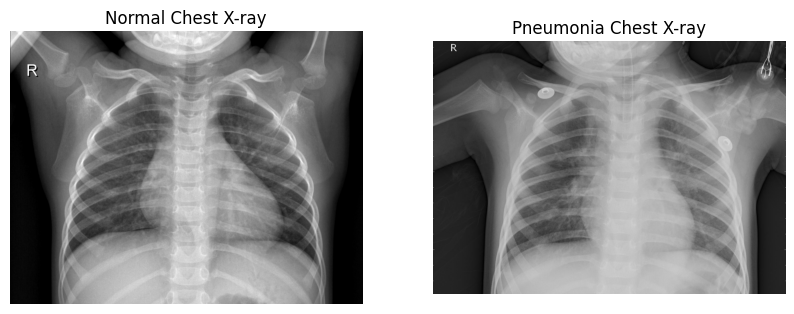

✅ Dataset explored


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

normal_sample = plt.imread(f"{data_path}/train/NORMAL/" + os.listdir(f"{data_path}/train/NORMAL")[0])
pneumonia_sample = plt.imread(f"{data_path}/train/PNEUMONIA/" + os.listdir(f"{data_path}/train/PNEUMONIA")[0])

axes[0].imshow(normal_sample, cmap='gray')
axes[0].set_title("Normal Chest X-ray")
axes[0].axis('off')

axes[1].imshow(pneumonia_sample, cmap='gray')
axes[1].set_title("Pneumonia Chest X-ray")
axes[1].axis('off')

plt.show()
print("✅ Dataset explored")


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

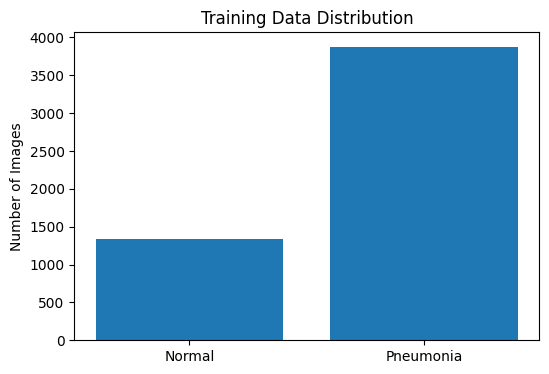

In [9]:
labels = ['Normal', 'Pneumonia']
counts = [train_normal, train_pneumonia]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.show()

In [10]:
train_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    f"{data_path}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [13]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [14]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.7716 - loss: 0.4834 - val_accuracy: 0.9089 - val_loss: 0.2612
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 905ms/step - accuracy: 0.8682 - loss: 0.3012 - val_accuracy: 0.9118 - val_loss: 0.2206
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8862 - loss: 0.2625 - val_accuracy: 0.9358 - val_loss: 0.1971
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9053 - loss: 0.2400 - val_accuracy: 0.9358 - val_loss: 0.1880
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 915ms/step - accuracy: 0.9077 - loss: 0.2260 - val_accuracy: 0.9291 - val_loss: 0.1892


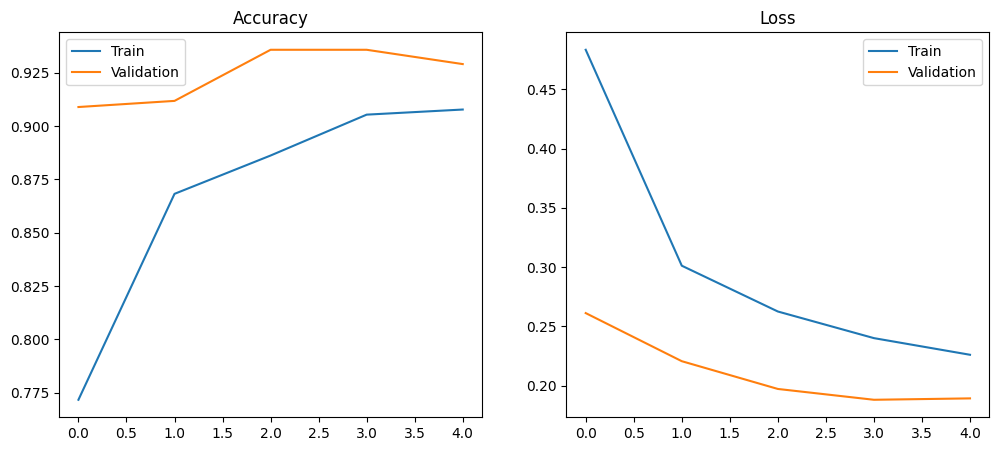

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [19]:
model.save("pneumonia_densenet.keras")

In [20]:
history.history['val_accuracy'][-1]

0.9290508031845093

In [21]:
model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 920ms/step - accuracy: 0.8766 - loss: 0.3050


[0.30496567487716675, 0.8766025900840759]

In [25]:
import os

project_path = "/content/drive/MyDrive/Medical_Xray_Project"

folders = [
    "datasets",
    "models",
    "outputs",
    "reports",
    "app"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("✅ Project folder created successfully!")

✅ Project folder created successfully!


In [26]:
model.save("/content/drive/MyDrive/Medical_Xray_Project/models/pneumonia_densenet.keras")

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [28]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      NORMAL       0.89      0.77      0.82       234
   PNEUMONIA       0.87      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.86       624
weighted avg       0.88      0.88      0.87       624



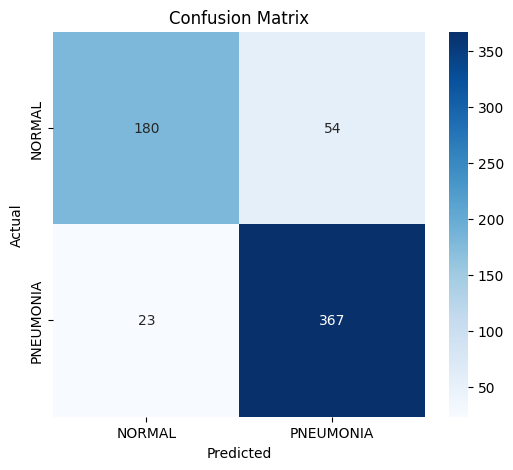

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

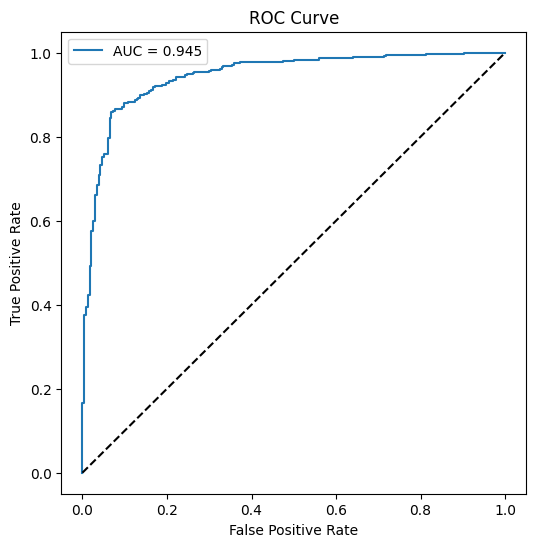

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_classes, predictions)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()